# 🗄️ Notebook 05: Vector Stores

**LangChain 1.0.5+ | Mixed Level Class**

## 🎯 Objectives
1. Understand vector stores
2. Use InMemoryVectorStore (testing)
3. Use FAISS (production)
4. Use Chroma (persistent)
5. Compare vector stores

In [1]:
from dotenv import load_dotenv
from pathlib import Path
load_dotenv()
print("✅ Setup complete")

✅ Setup complete


## 1. What are Vector Stores? 🤔

### 🔰 BEGINNER

**Vector Stores** are databases optimized for finding similar vectors.

Like a library:
- Traditional database: "Find book with ISBN 12345"
- Vector store: "Find books similar to this topic"

They enable **semantic search**!

## 2. InMemoryVectorStore (Simple)

In [2]:
from langchain_core.vectorstores import InMemoryVectorStore
from langchain_openai import OpenAIEmbeddings
from langchain_core.documents import Document

# Initialize
embeddings = OpenAIEmbeddings(model="text-embedding-3-small")
vector_store = InMemoryVectorStore(embedding=embeddings)

# Add documents
docs = [
    Document(page_content="Python is a programming language"),
    Document(page_content="Machine learning uses algorithms"),
    Document(page_content="The sun is a star")
]

vector_store.add_documents(docs)
print(f"✅ Added {len(docs)} documents\n")

# Search
results = vector_store.similarity_search("What is Python?", k=2)

print("Search Results:")
for i, doc in enumerate(results, 1):
    print(f"{i}. {doc.page_content}")

✅ Added 3 documents

Search Results:
1. Python is a programming language
2. Machine learning uses algorithms


## 3. FAISS (Fast & Production-Ready)

In [ ]:
from langchain_community.vectorstores import FAISS
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from pathlib import Path

# Load and split a PDF
pdf_path = "attention.pdf"

if Path(pdf_path).exists():
    print("Loading PDF...")
    loader = PyPDFLoader(pdf_path)
    documents = loader.load()
    
    # Split
    splitter = RecursiveCharacterTextSplitter(
        chunk_size=1000,
        chunk_overlap=200
    )
    chunks = splitter.split_documents(documents)
    print(f"Split into {len(chunks)} chunks")
    
    # Create FAISS vectorstore # Convert text → vector (numbers) using embeddings # Store in FAISS index
    print("Creating embeddings (this may take a minute)...")
    vectorstore = FAISS.from_documents(chunks, embeddings)
    
    # Save to disk
    vectorstore.save_local("./faiss_index_notebook")
    print("✅ FAISS index saved\n")
    
    # Search
    query = "What is attention mechanism?"
    results = vectorstore.similarity_search(query, k=3)
    
    print(f"Query: {query}\n")
    for i, doc in enumerate(results, 1):
        print(f"Result {i}:")
        print(f"  {doc.page_content[:150]}...\n")
else:
    print(f"❌ PDF not found: {pdf_path}")

Loading PDF...
Split into 52 chunks
Creating embeddings (this may take a minute)...
✅ FAISS index saved

Query: What is attention mechanism?

Result 1:
  Attention Visualizations
Input-Input Layer5
It
is
in
this
spirit
that
a
majority
of
American
governments
have
passed
new
laws
since
2009
making
the
re...

Result 2:
  3.2 Attention
An attention function can be described as mapping a query and a set of key-value pairs to an output,
where the query, keys, values, and ...

Result 3:
  Provided proper attribution is provided, Google hereby grants permission to
reproduce the tables and figures in this paper solely for use in journalis...



## 4. Loading Existing FAISS Index
Above FAISS index
Note:-👌 this is the next step after saving FAISS — now you’re loading and reusing it instead of creating it again.

In [4]:
# Load existing index
if Path("./faiss_index_notebook").exists():
    loaded_vectorstore = FAISS.load_local(
        "./faiss_index_notebook",
        embeddings,
        allow_dangerous_deserialization=True
    )
    print("✅ Loaded existing FAISS index")
    
    # Use it
    results = loaded_vectorstore.similarity_search("transformers", k=2)
    print(f"\nFound {len(results)} results")
else:
    print("No existing index found")

✅ Loaded existing FAISS index

Found 2 results


🧠 Big Idea

👉 Earlier:

You created a vector database
You saved it

👉 Now:

You are loading it back
And using it to search again

🚀 Why this is important

Without this:
❌ You recreate embeddings every time (slow + costly)

With this:
✅ Fast
✅ Efficient
✅ Production-ready approach

## 5. Chroma (Persistent & Easy)

In [ ]:
!uv pip install langchain-chroma chromadb

Resolved 93 packages in 914ms                                        
⠙ Preparing packages... (0/14)                                                  
⠙ Preparing packages... (0/14)------------     0 B/70.83 KiB            
⠙ Preparing packages... (0/14)------------ 14.84 KiB/70.83 KiB          
opentelemetry-proto ------------------------------ 14.84 KiB/70.83 KiB
⠙ Preparing packages... (0/14)----------     0 B/129.25 KiB             
opentelemetry-proto ------------------------------ 14.84 KiB/70.83 KiB
⠙ Preparing packages... (0/14)---------- 14.84 KiB/129.25 KiB           
typer      ------------------------------     0 B/45.93 KiB
opentelemetry-proto ------------------------------ 14.84 KiB/70.83 KiB
⠙ Preparing packages... (0/14)---------- 14.84 KiB/129.25 KiB           
typer      ------------------------------ 14.89 KiB/45.93 KiB
opentelemetry-proto ------------------------------ 14.84 KiB/70.83 KiB
⠙ Preparing packages... (0/14)---------- 14.84 KiB/129.25 KiB           
typer

In [ ]:
from langchain_chroma import Chroma

# Create Chroma vectorstore
chroma_store = Chroma(
    collection_name="my_collection",
    embedding_function=embeddings,
    persist_directory="./chroma_db_notebook"
)

# Add documents
sample_docs = [
    Document(
        page_content="RAG combines retrieval and generation",
        metadata={"topic": "rag", "difficulty": "intermediate"}
    ),
    Document(
        page_content="LangChain simplifies LLM applications",
        metadata={"topic": "langchain", "difficulty": "beginner"}
    )
]

chroma_store.add_documents(sample_docs)
print("✅ Added documents to Chroma\n")

# Search with metadata filter
results = chroma_store.similarity_search(
    "Tell me about RAG",
    k=2,
    filter={"topic": "rag"}
)

print("Filtered search results:")
for doc in results:
    print(f"  {doc.page_content}")
    print(f"  Metadata: {doc.metadata}")
    

# Without metadata:
# 👉 Search = “find similar text”
# With metadata:
# 👉 Search = “find similar text BUT only from a specific category”   

✅ Added documents to Chroma

Filtered search results:
  RAG combines retrieval and generation
  Metadata: {'topic': 'rag', 'difficulty': 'intermediate'}


## 6. Vector Store Comparison

| Store | Persistent | Speed | Metadata Filtering | Best For |
|-------|-----------|-------|-------------------|----------|
| **InMemory** | ❌ | ⚡⚡⚡ | ❌ | Testing |
| **FAISS** | ✅ | ⚡⚡⚡ | Limited | Production, Speed |
| **Chroma** | ✅ | ⚡⚡ | ✅ | Development, Filtering |

## Summary

✅ Vector stores enable semantic search
✅ InMemory for testing
✅ FAISS for speed and scale
✅ Chroma for metadata filtering
✅ Always persist for production!

**Next:** Retrieval Strategies!

=============================================

| Feature         | FAISS       | Chroma   |
| --------------- | ----------- | -------- |
| Speed           | Very fast ⚡ | Fast     |
| Metadata filter | ❌           | ✅        |
| Persistence     | Manual      | Built-in |
| Easy to use     | Medium      | Easy     |



=======================================================






![Document storage and similarity search flow.png](<attachment:Document storage and similarity search flow.png>)


Without metadata:

👉 Search = “find similar text”

With metadata:

👉 Search = “find similar text BUT only from a specific category”

====================================================================================
![Vector database comparison infographic.png](<attachment:Vector database comparison infographic.png>)
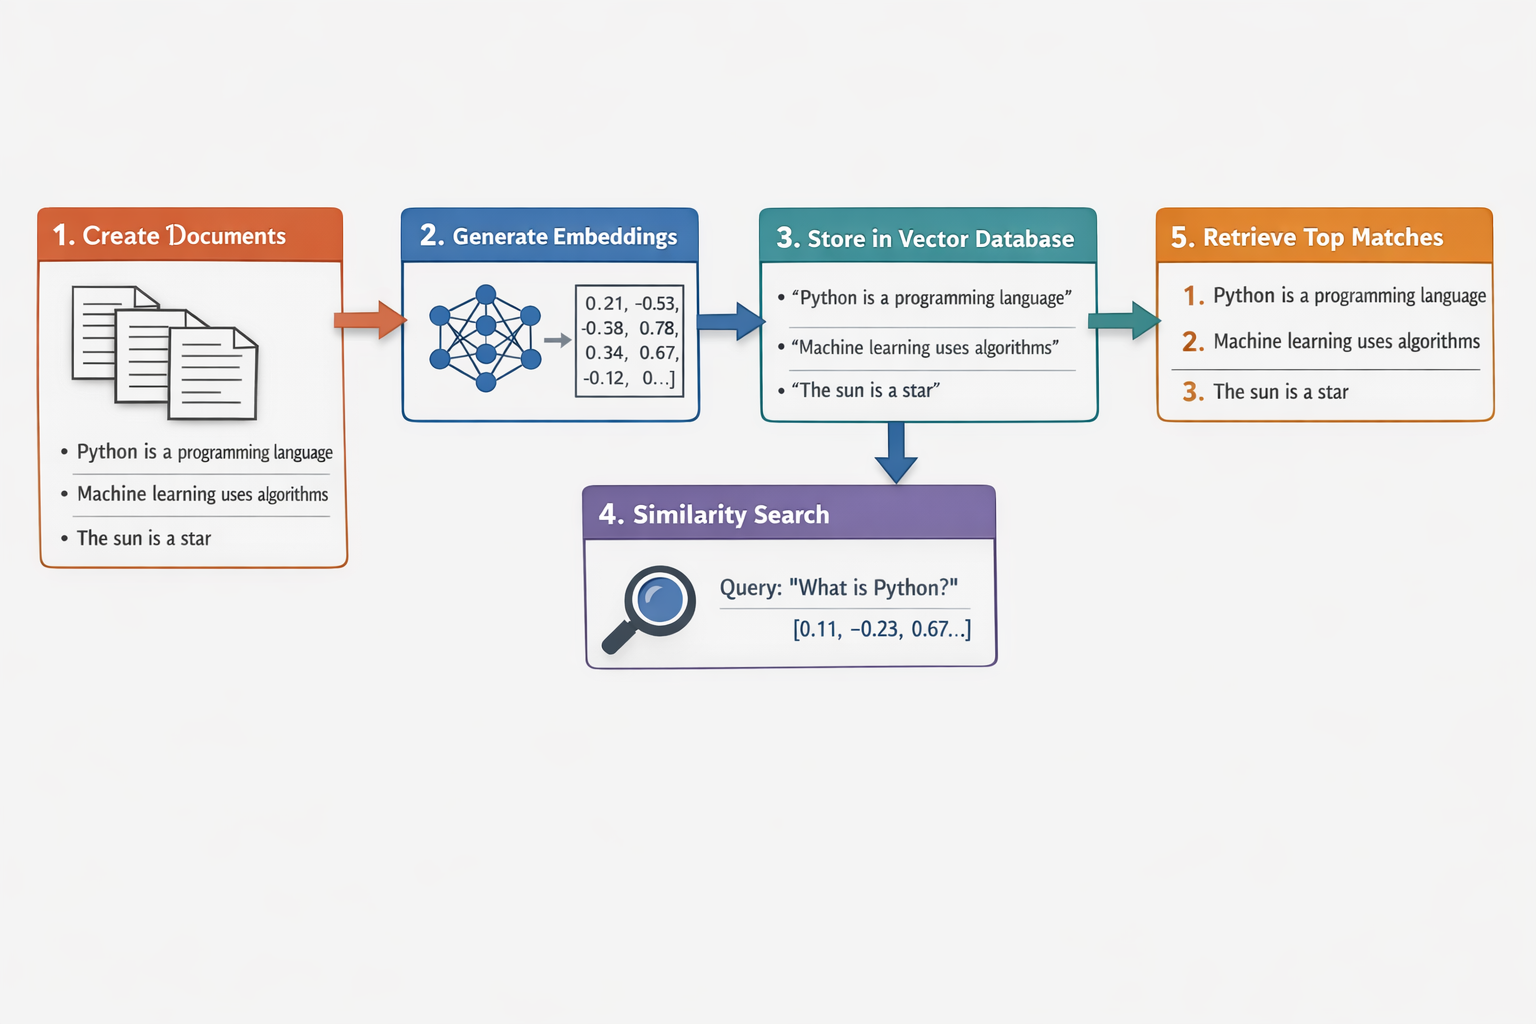
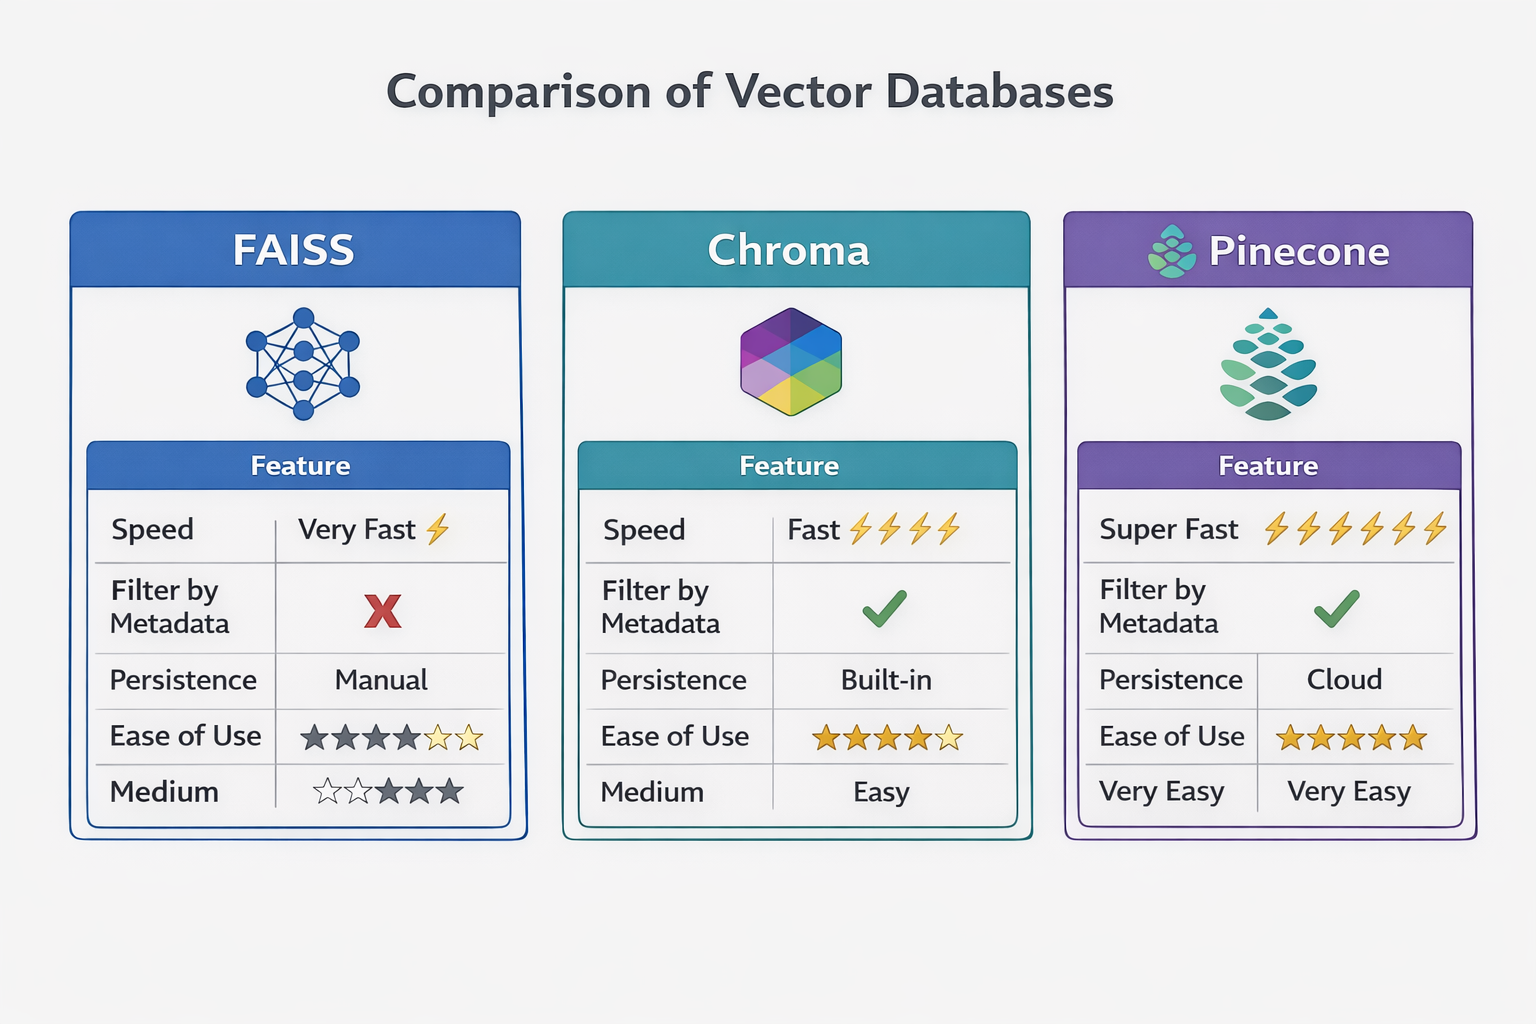